# Flood exposure

In [1]:
%load_ext jupyter_black
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import geopandas as gpd
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

from src.datasources import worldpop, codab, floodscan, abn, hydrosheds
from src.constants import *
from src.utils import shift_to_floodseason

In [3]:
level = abn.load_abn_niamey().reset_index()
level = level.rename(columns={"Date": "time", "Water Level (cm)": "level"})
level = shift_to_floodseason(level, date_col="time")
# drop duplicates due to leapyears (just on Jan 1)
level = level[~level.duplicated(subset=["dayofseason", "seasonyear"])]
# keep only full seasons
level = level[level["seasonyear"].isin(range(2005, 2022))]
level

,time,level,Discharges (m3/s),dayofseason,seasonyear
516,2006-06-01,127.667,53.760,1,2005
517,2006-06-02,126.667,52.200,2,2005
518,2006-06-03,127.000,52.720,3,2005
519,2006-06-04,127.000,52.720,4,2005
155,2005-06-05,181.000,157.467,5,2005
...,...,...,...,...,...
6355,2022-05-27,185.000,81.740,361,2021
6356,2022-05-28,176.000,67.845,362,2021
6357,2022-05-29,174.000,64.920,363,2021
6358,2022-05-30,176.500,68.625,364,2021


In [16]:
peaks = level.groupby("seasonyear")["level"].max().reset_index()

In [17]:
peaks[peaks["level"] > 580]

,seasonyear,level
7,2012,616.667
8,2013,611.750
11,2016,602.667
12,2017,595.667
13,2018,592.000
14,2019,636.000
15,2020,699.333


In [23]:
(2023 - 2005 + 1) / 7

2.7142857142857144

In [181]:
level[level.duplicated(subset=["dayofseason", "seasonyear"])]

,time,level,Discharges (m3/s),dayofseason,seasonyear


<Axes: xlabel='dayofseason'>

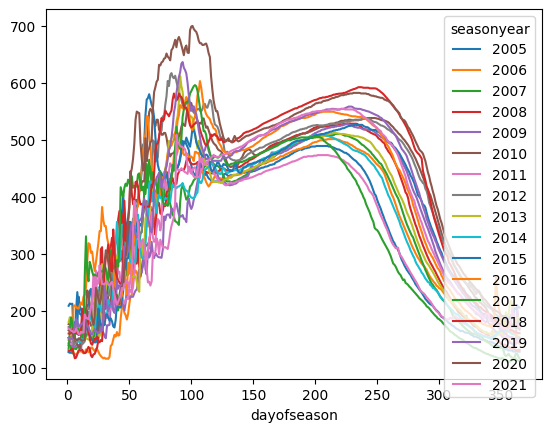

In [182]:
level.pivot(index="dayofseason", columns="seasonyear", values="level").plot()

In [4]:
# codab.download_codab()

In [255]:
adm3 = codab.load_codab(admin_level=3, aoi_only=True)
adm2 = codab.load_codab(admin_level=2, aoi_only=True)
adm1 = codab.load_codab(admin_level=1, aoi_only=True)

In [266]:
river = hydrosheds.load_niger_river()
river_aoi = gpd.sjoin(river, adm3, how="inner", predicate="intersects")

In [6]:
# floodscan.clip_ner_from_glb()

In [205]:
exp = floodscan.load_daily_exposure()

In [227]:
rolls = [1, 3, 5, 7, 9, 11]
for roll in rolls:
    exp[f"fs_roll{roll}"] = (
        exp.groupby("ADM3_PCODE")["total_exposed"]
        .transform(lambda x: x.rolling(window=roll, min_periods=roll).mean())
        .shift(-np.floor(roll / 2).astype(int))
    )

In [228]:
exp

,time,total_exposed,ADM3_PCODE,fs_roll1,fs_roll3,fs_roll5,fs_roll7,fs_roll9,fs_roll11
0,1998-01-12,0,NE003001001,0.0,NaN,NaN,NaN,NaN,NaN
1,1998-01-13,0,NE003001001,0.0,0.0,NaN,NaN,NaN,NaN
2,1998-01-14,0,NE003001001,0.0,0.0,0.0,NaN,NaN,NaN
3,1998-01-15,0,NE003001001,0.0,0.0,0.0,0.0,NaN,NaN
4,1998-01-16,0,NE003001001,0.0,0.0,0.0,0.0,0.111111,NaN
...,...,...,...,...,...,...,...,...,...
882100,2023-12-27,0,NE008001005,0.0,0.0,0.0,0.0,0.000000,NaN
882101,2023-12-28,0,NE008001005,0.0,0.0,0.0,0.0,NaN,NaN
882102,2023-12-29,0,NE008001005,0.0,0.0,0.0,NaN,NaN,NaN
882103,2023-12-30,0,NE008001005,0.0,0.0,NaN,NaN,NaN,NaN


In [229]:
exp_f = exp[exp["ADM3_PCODE"] == GAYA].copy().sort_values("time")
exp_f = shift_to_floodseason(exp_f, date_col="time")
exp_f

,time,total_exposed,ADM3_PCODE,fs_roll1,fs_roll3,fs_roll5,fs_roll7,fs_roll9,fs_roll11,dayofseason,seasonyear
11468,1998-06-01,0,NE003006003,0.0,0.0,0.0,0.0,0.0,0.0,1,1997
11469,1998-06-02,0,NE003006003,0.0,0.0,0.0,0.0,0.0,0.0,2,1997
11470,1998-06-03,0,NE003006003,0.0,0.0,0.0,0.0,0.0,0.0,3,1997
11471,1998-06-04,0,NE003006003,0.0,0.0,0.0,0.0,0.0,0.0,4,1997
11328,1998-01-12,0,NE003006003,0.0,NaN,NaN,NaN,NaN,NaN,226,1997
...,...,...,...,...,...,...,...,...,...,...,...
860200,2023-12-27,0,NE003006003,0.0,0.0,0.0,0.0,0.0,0.0,210,2023
860201,2023-12-28,0,NE003006003,0.0,0.0,0.0,0.0,0.0,0.0,211,2023
860202,2023-12-29,0,NE003006003,0.0,0.0,0.0,0.0,0.0,0.0,212,2023
860203,2023-12-30,0,NE003006003,0.0,0.0,0.0,0.0,0.0,0.0,213,2023


In [235]:
exp_max = (
    exp.groupby(["ADM3_PCODE", exp["time"].dt.year])
    .max()
    .drop(columns="time")
    .reset_index()
)
exp_max_mean = (
    exp_max.groupby("ADM3_PCODE").mean().drop(columns="time").reset_index()
)

In [236]:
exp_max_mean.merge(
    adm3[["ADM3_PCODE", "ADM3_FR"]], on="ADM3_PCODE"
).sort_values("total_exposed", ascending=False).iloc[:10]

,ADM3_PCODE,total_exposed,fs_roll1,fs_roll3,fs_roll5,fs_roll7,fs_roll9,fs_roll11,ADM3_FR
32,NE003006003,8031.576923,8031.576923,6504.833333,5440.015385,4906.236264,4507.598291,4120.409091,Gaya
91,NE008001004,5509.230769,5509.230769,1861.705128,1118.323077,802.741758,624.354701,510.835664,Niamey IV
88,NE008001001,4812.115385,4812.115385,1635.410256,981.246154,712.604396,554.247863,453.475524,Niamey I
34,NE003006005,3817.692308,3817.692308,3220.410256,2936.846154,2753.774725,2625.410256,2523.751748,Tounouga
33,NE003006004,3808.846154,3808.846154,2996.743590,2573.938462,2276.351648,2033.517094,1923.965035,Tanda
42,NE003008004,3755.423077,3755.423077,2332.589744,1728.361538,1256.175824,1002.252137,847.944056,Tibiri
92,NE008001005,3668.692308,3668.692308,1273.179487,763.907692,549.137363,427.106838,349.451049,Niamey V
54,NE006007001,3485.384615,3485.384615,1950.743590,1214.592308,872.615385,678.747863,569.167832,Dargol
24,NE003004008,2987.961538,2987.961538,2174.076923,1792.453846,1534.538462,1312.128205,1216.370629,Sambéra
28,NE003005001,2878.346154,2878.346154,1907.346154,1424.100000,1125.934066,915.012821,770.367133,Falmey


<Axes: xlabel='time'>

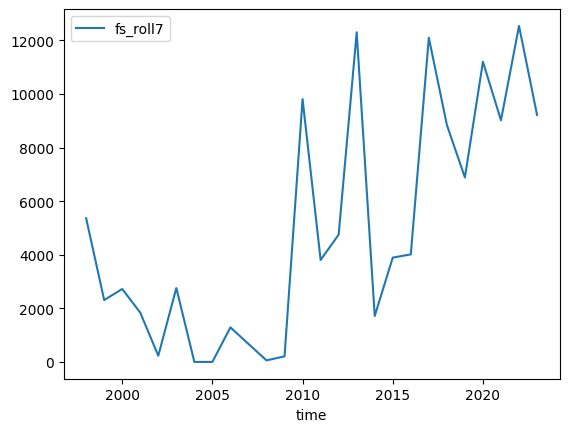

In [241]:
exp_max[exp_max["ADM3_PCODE"] == GAYA].plot(x="time", y="fs_roll7")

In [242]:
compare = exp.merge(level, on="time")

<Axes: xlabel='dayofseason'>

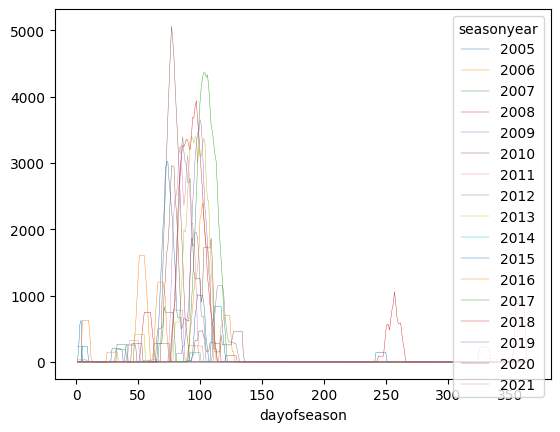

In [254]:
compare_f = compare[compare["ADM3_PCODE"] == TANDA]
compare_f.pivot(
    index="dayofseason",
    columns="seasonyear",
    values="fs_roll9",
).plot(linewidth=0.3)

In [108]:
dicts = []

for pcode, group in compare.groupby("ADM3_PCODE"):
    corr = (
        group[["total_exposed", "level"]].corr().loc["level", "total_exposed"]
    )
    # dicts

In [107]:
corr

0.008107128215363751

In [54]:
exp_max_mean

,ADM3_PCODE,time,total_exposed
0,NE003001001,2010.5,2524.653846
1,NE003001002,2010.5,2259.461538
2,NE003001003,2010.5,246.192308
3,NE003001004,2010.5,325.038462
4,NE003001005,2010.5,536.192308
...,...,...,...
88,NE008001001,2010.5,4812.115385
89,NE008001002,2010.5,464.346154
90,NE008001003,2010.5,1112.769231
91,NE008001004,2010.5,5509.230769


In [56]:
adm3

,ADM3_FR,ADM3_PCODE,ADM2_FR,ADM2_PCODE,ADM1_FR,ADM1_PCODE,ADM0_FR,ADM0_PCODE,DATE,VALIDON,VALIDTO,geometry
27,Birni N'Gaouré,NE003001001,Boboye,NE003001,Dosso,NE003,Niger (the),NE,2023-06-21,2023-07-25,NaN,"POLYGON ((2.99792 13.11511, 2.99670 13.10687, ..."
28,Fabidji,NE003001002,Boboye,NE003001,Dosso,NE003,Niger (the),NE,2023-06-21,2023-07-25,NaN,"POLYGON ((2.52972 13.05353, 2.56488 13.05212, ..."
29,Fakara,NE003001003,Boboye,NE003001,Dosso,NE003,Niger (the),NE,2023-06-21,2023-07-25,NaN,"POLYGON ((2.74512 13.15833, 2.73749 13.14410, ..."
30,Harikanassou,NE003001004,Boboye,NE003001,Dosso,NE003,Niger (the),NE,2023-06-21,2023-07-25,NaN,"POLYGON ((2.92548 13.38971, 2.92969 13.38013, ..."
31,Kankandi,NE003001005,Boboye,NE003001,Dosso,NE003,Niger (the),NE,2023-06-21,2023-07-25,NaN,"POLYGON ((2.98010 12.92230, 2.96588 12.89850, ..."
...,...,...,...,...,...,...,...,...,...,...,...,...
261,Niamey I,NE008001001,Ville de Niamey,NE008001,Niamey,NE008,Niger (the),NE,2023-06-21,2023-07-25,NaN,"POLYGON ((2.10773 13.59192, 2.11169 13.55170, ..."
262,Niamey II,NE008001002,Ville de Niamey,NE008001,Niamey,NE008,Niger (the),NE,2023-06-21,2023-07-25,NaN,"POLYGON ((2.13330 13.55969, 2.13531 13.55408, ..."
263,Niamey III,NE008001003,Ville de Niamey,NE008001,Niamey,NE008,Niger (the),NE,2023-06-21,2023-07-25,NaN,"POLYGON ((2.25170 13.63095, 2.25153 13.62750, ..."
264,Niamey IV,NE008001004,Ville de Niamey,NE008001,Niamey,NE008,Niger (the),NE,2023-06-21,2023-07-25,NaN,"POLYGON ((2.22491 13.46948, 2.21393 13.46008, ..."


Text(0.5, 1.0, 'Population moyenne exposée aux inondations (1998-2023)')

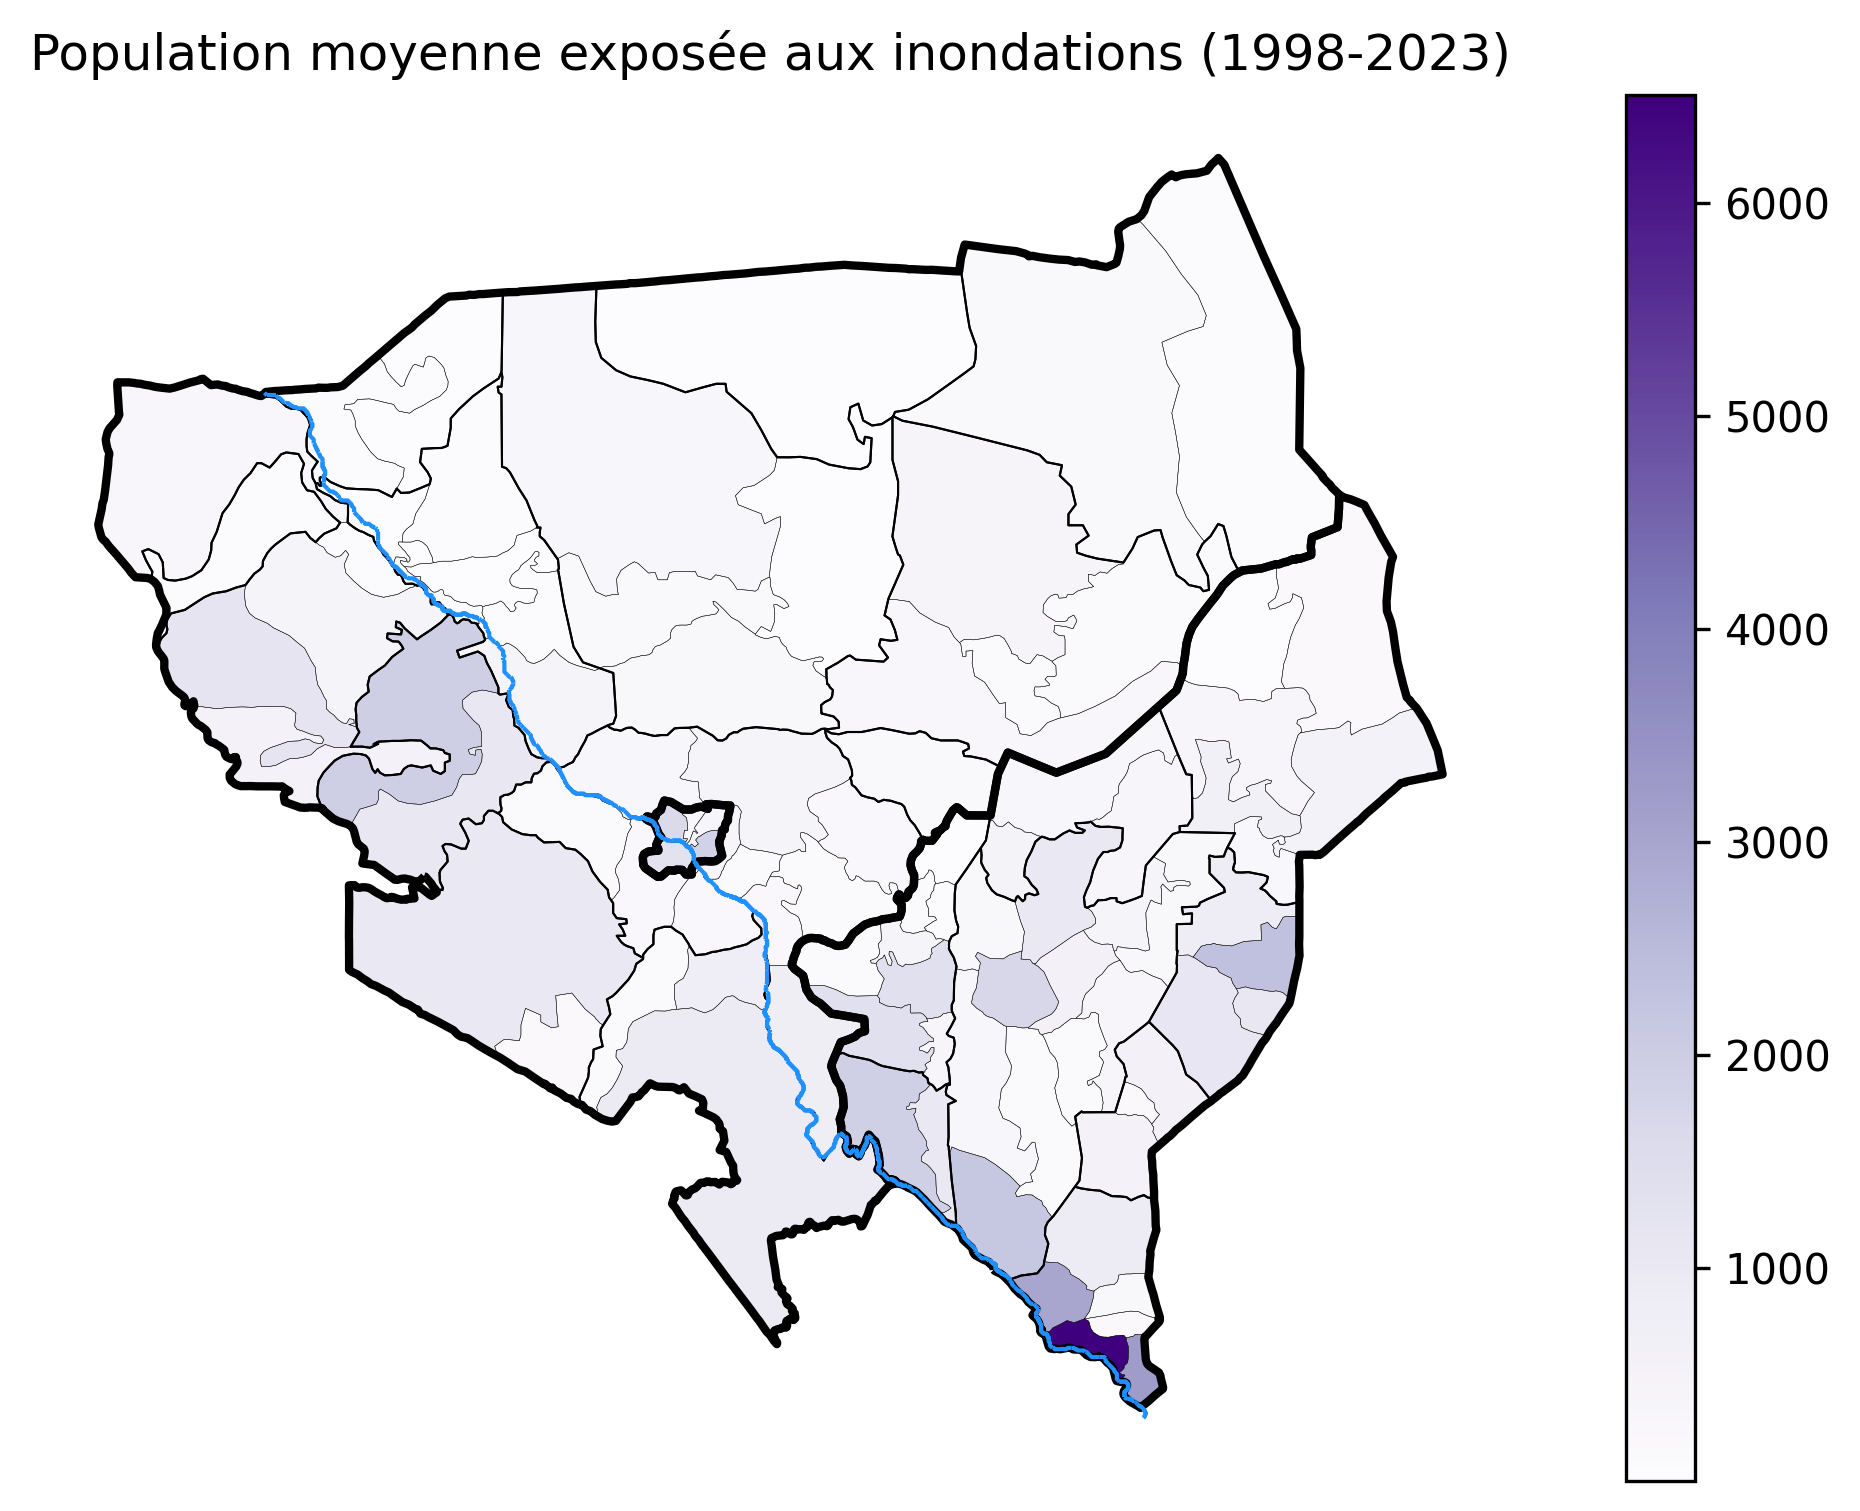

In [278]:
fig, ax = plt.subplots(figsize=(10, 6), dpi=300)
ax = adm3.merge(exp_max_mean, on="ADM3_PCODE").plot(
    column="fs_roll3", cmap="Purples", ax=ax, legend=True
)
adm3.boundary.plot(ax=ax, color="k", linewidth=0.1)
adm2.boundary.plot(ax=ax, color="k", linewidth=0.5)
adm1.boundary.plot(ax=ax, color="k", linewidth=2)
river_aoi.plot(ax=ax, color="dodgerblue", linewidth=1)
ax.axis("off")
ax.set_title("Population moyenne exposée aux inondations (1998-2023)")

In [285]:
exp_max

,ADM3_PCODE,time,total_exposed,fs_roll1,fs_roll3,fs_roll5,fs_roll7,fs_roll9,fs_roll11
0,NE003001001,1998,6728,6728.0,6668.000000,4001.0,2858.000000,2223.000000,1819.000000
1,NE003001001,1999,8774,8774.0,7695.333333,4853.2,3484.571429,2710.222222,2217.454545
2,NE003001001,2000,4653,4653.0,2145.666667,1299.2,1060.142857,831.111111,686.272727
3,NE003001001,2001,6459,6459.0,2153.333333,1292.6,923.714286,718.444444,587.818182
4,NE003001001,2002,1560,1560.0,547.666667,328.6,234.714286,182.555556,149.363636
...,...,...,...,...,...,...,...,...,...
2413,NE008001005,2019,0,0.0,0.000000,0.0,0.000000,0.000000,0.000000
2414,NE008001005,2020,830,830.0,490.666667,294.4,210.285714,163.555556,133.818182
2415,NE008001005,2021,0,0.0,0.000000,0.0,0.000000,0.000000,0.000000
2416,NE008001005,2022,0,0.0,0.000000,0.0,0.000000,0.000000,0.000000


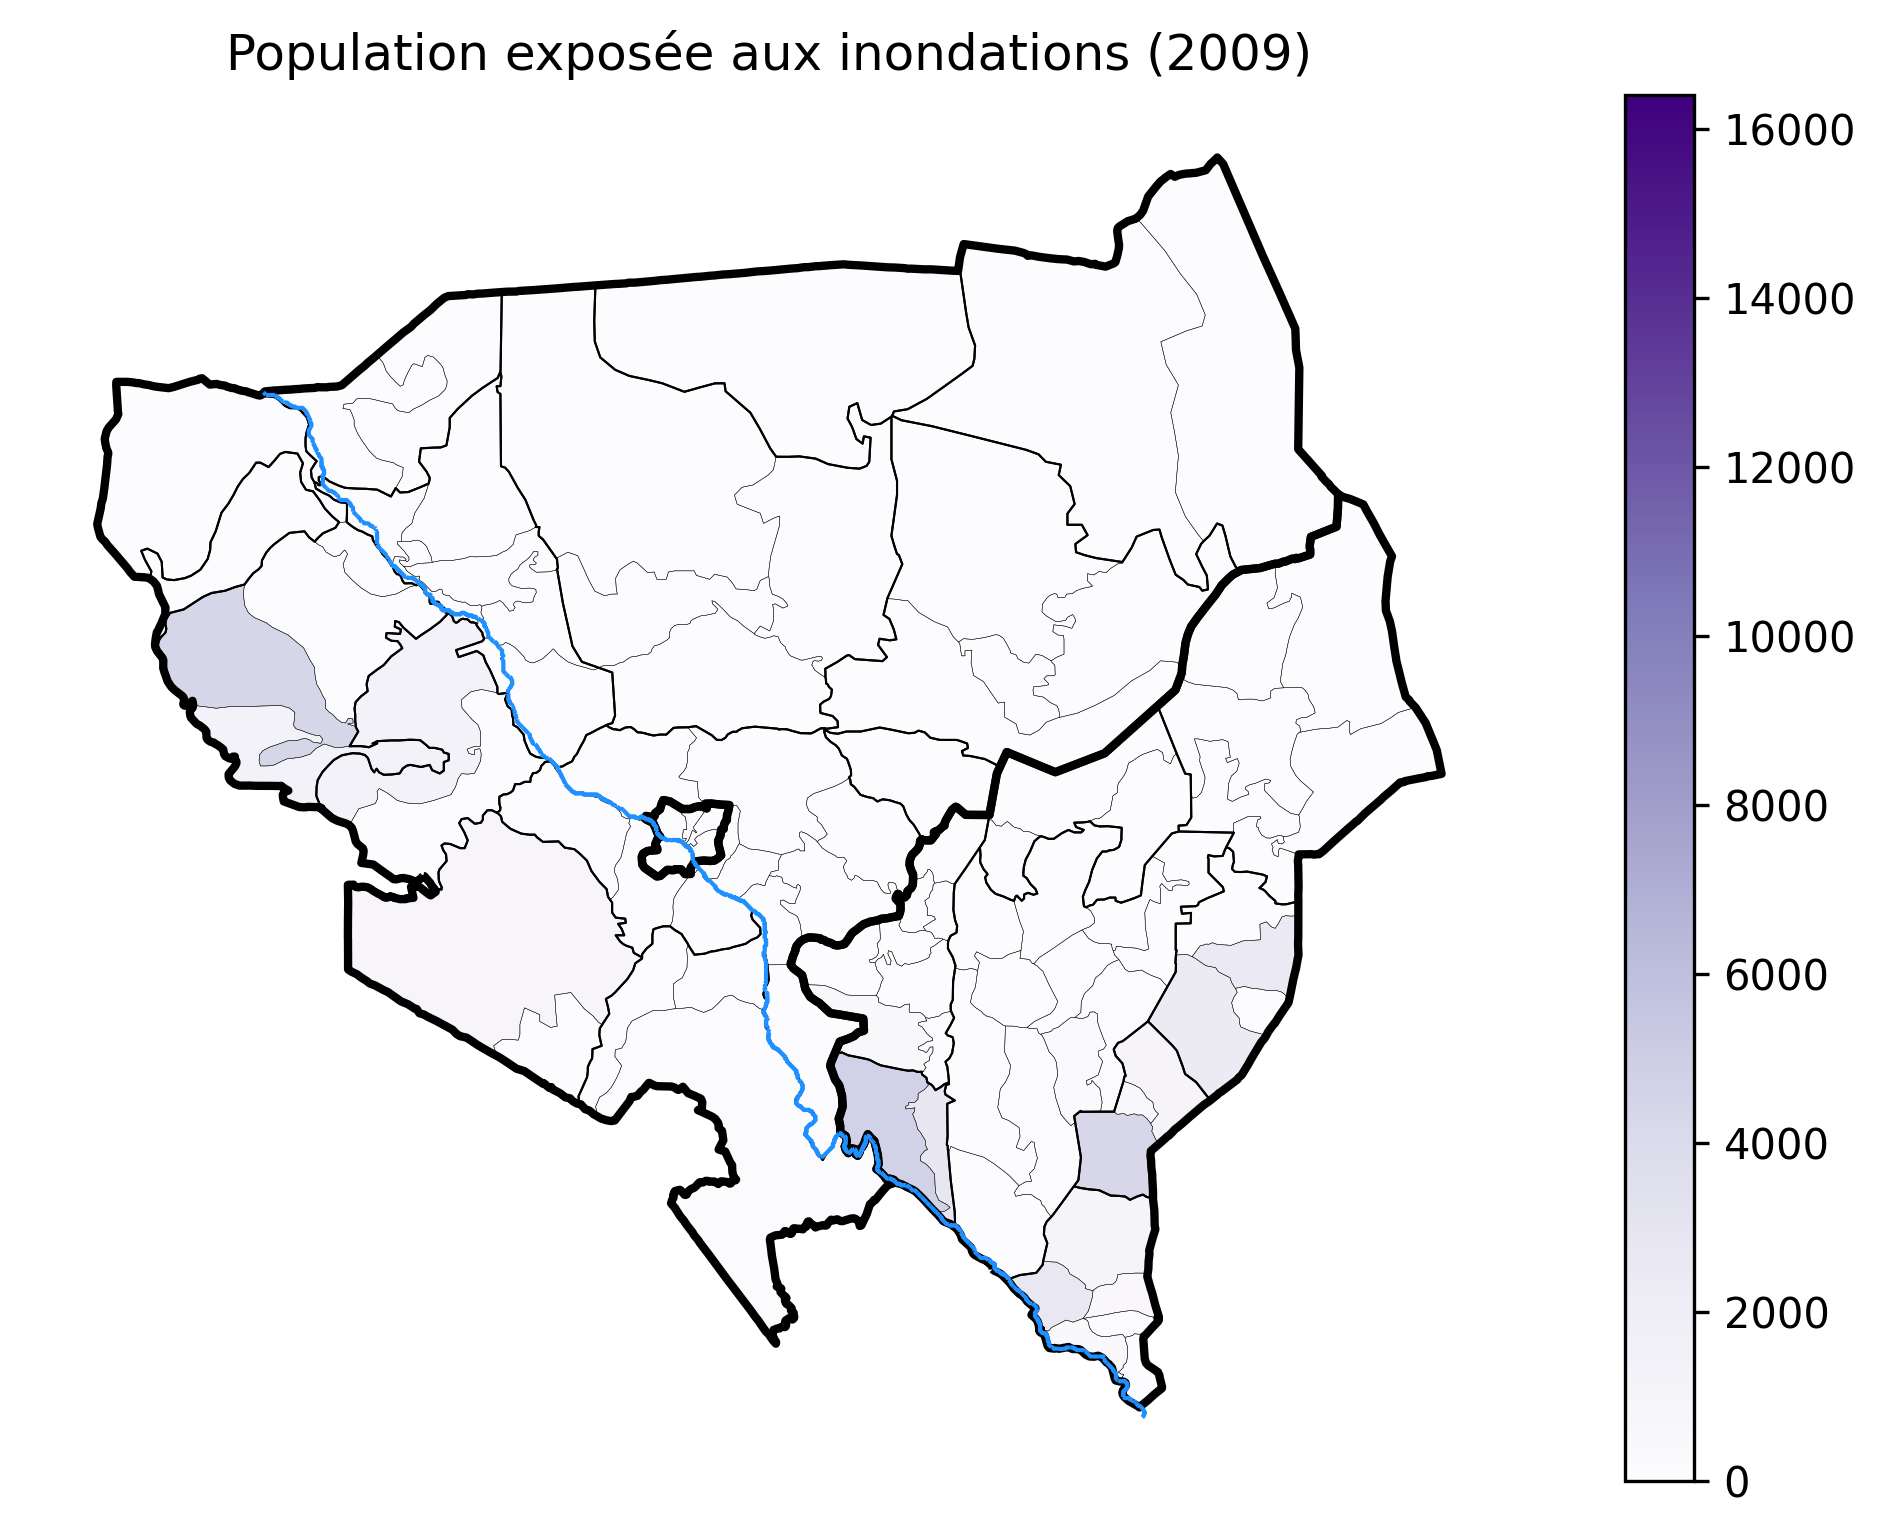

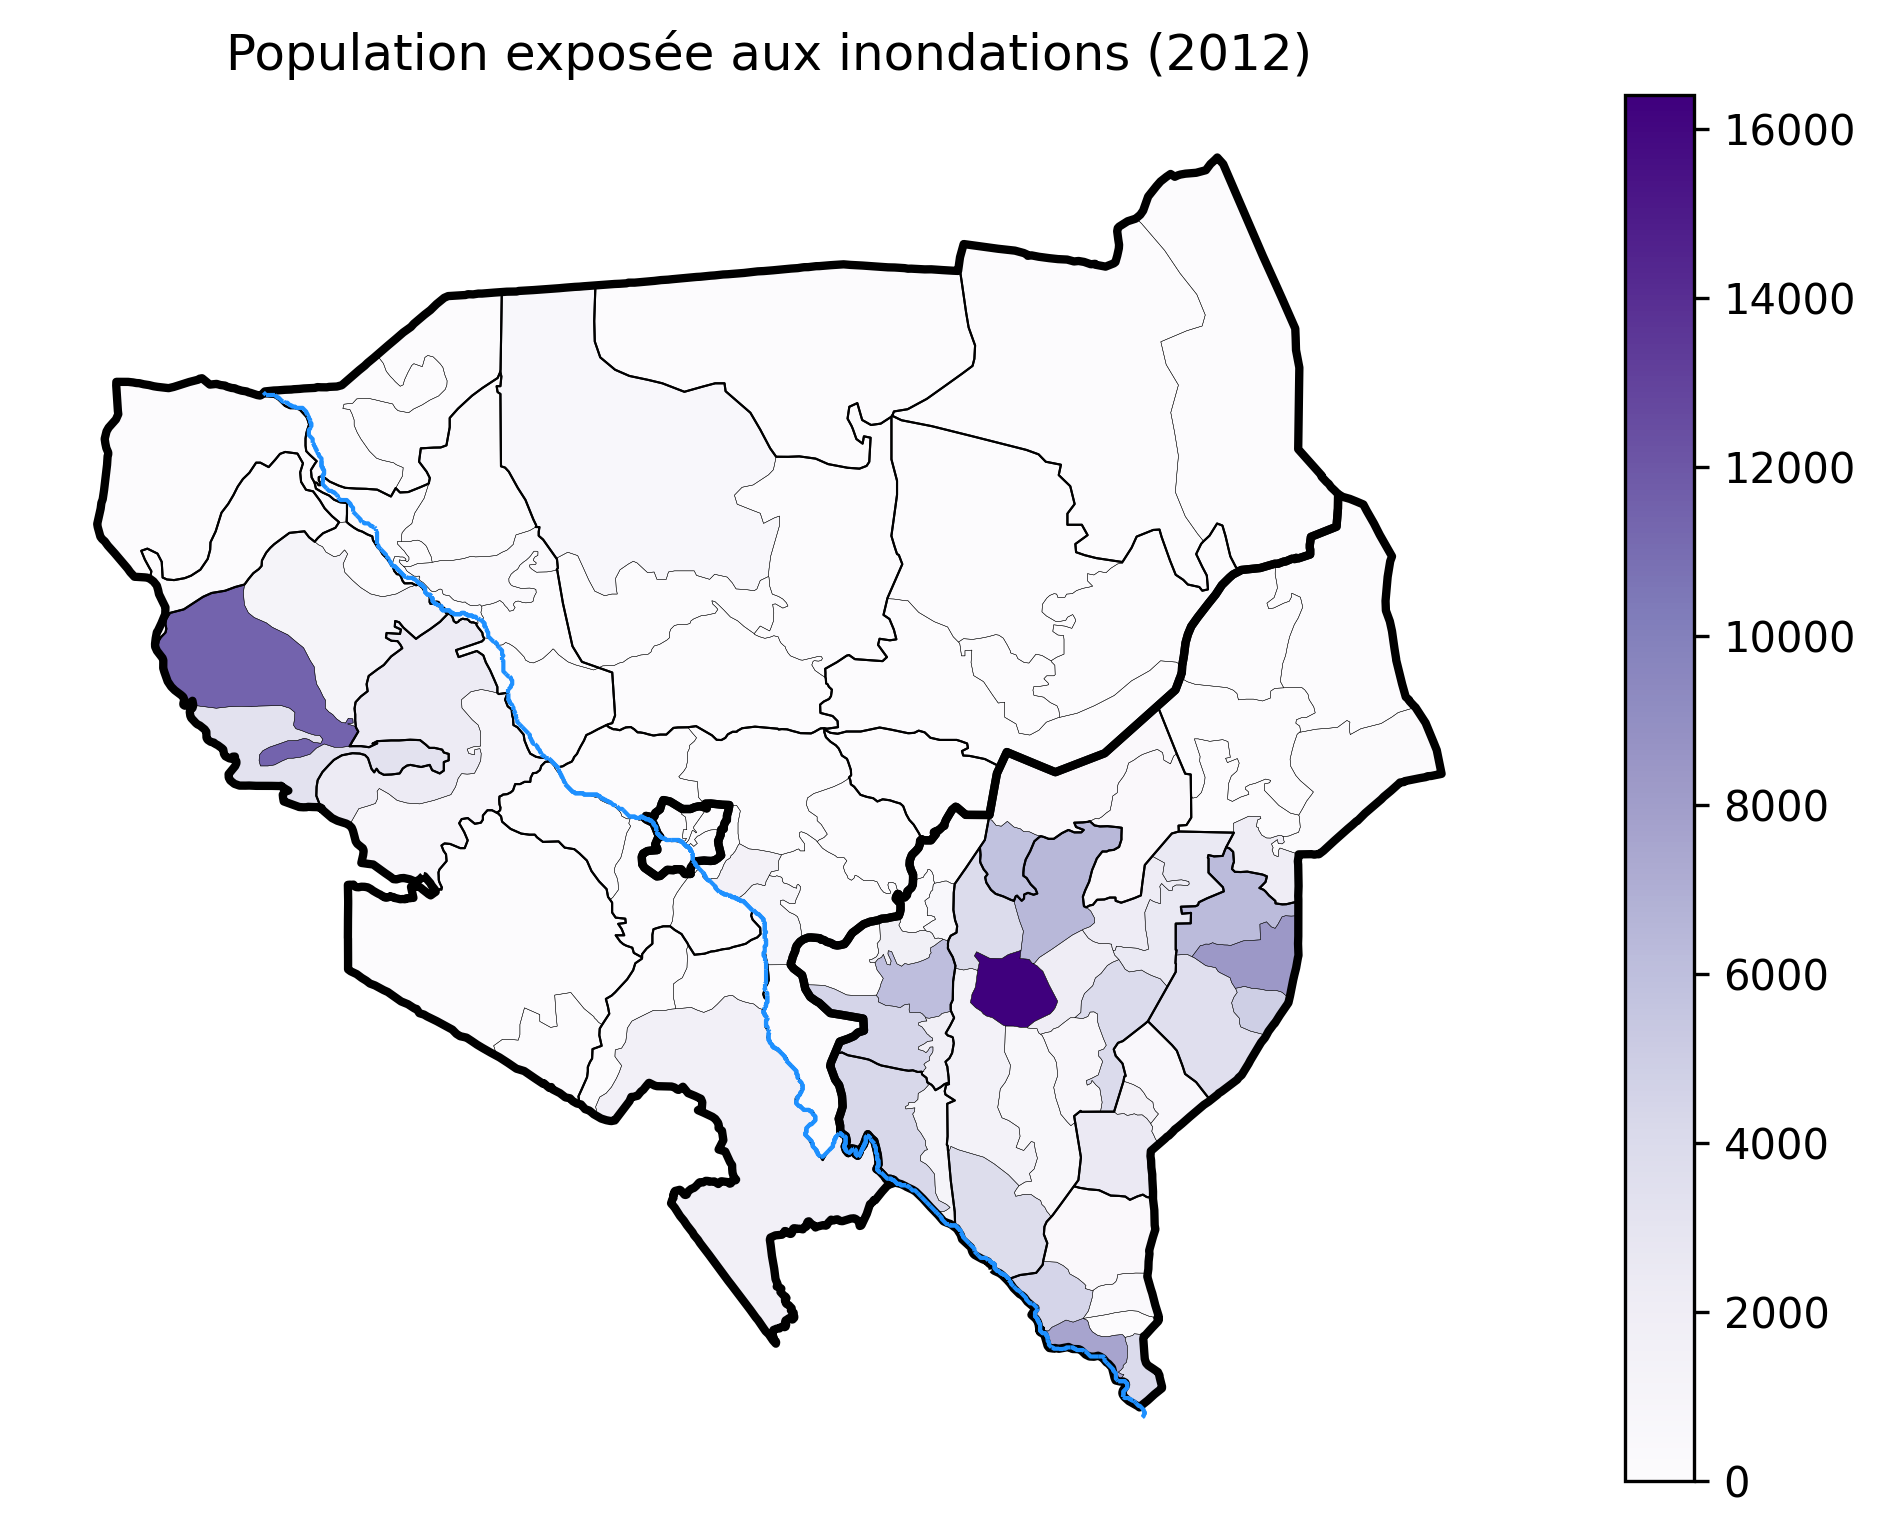

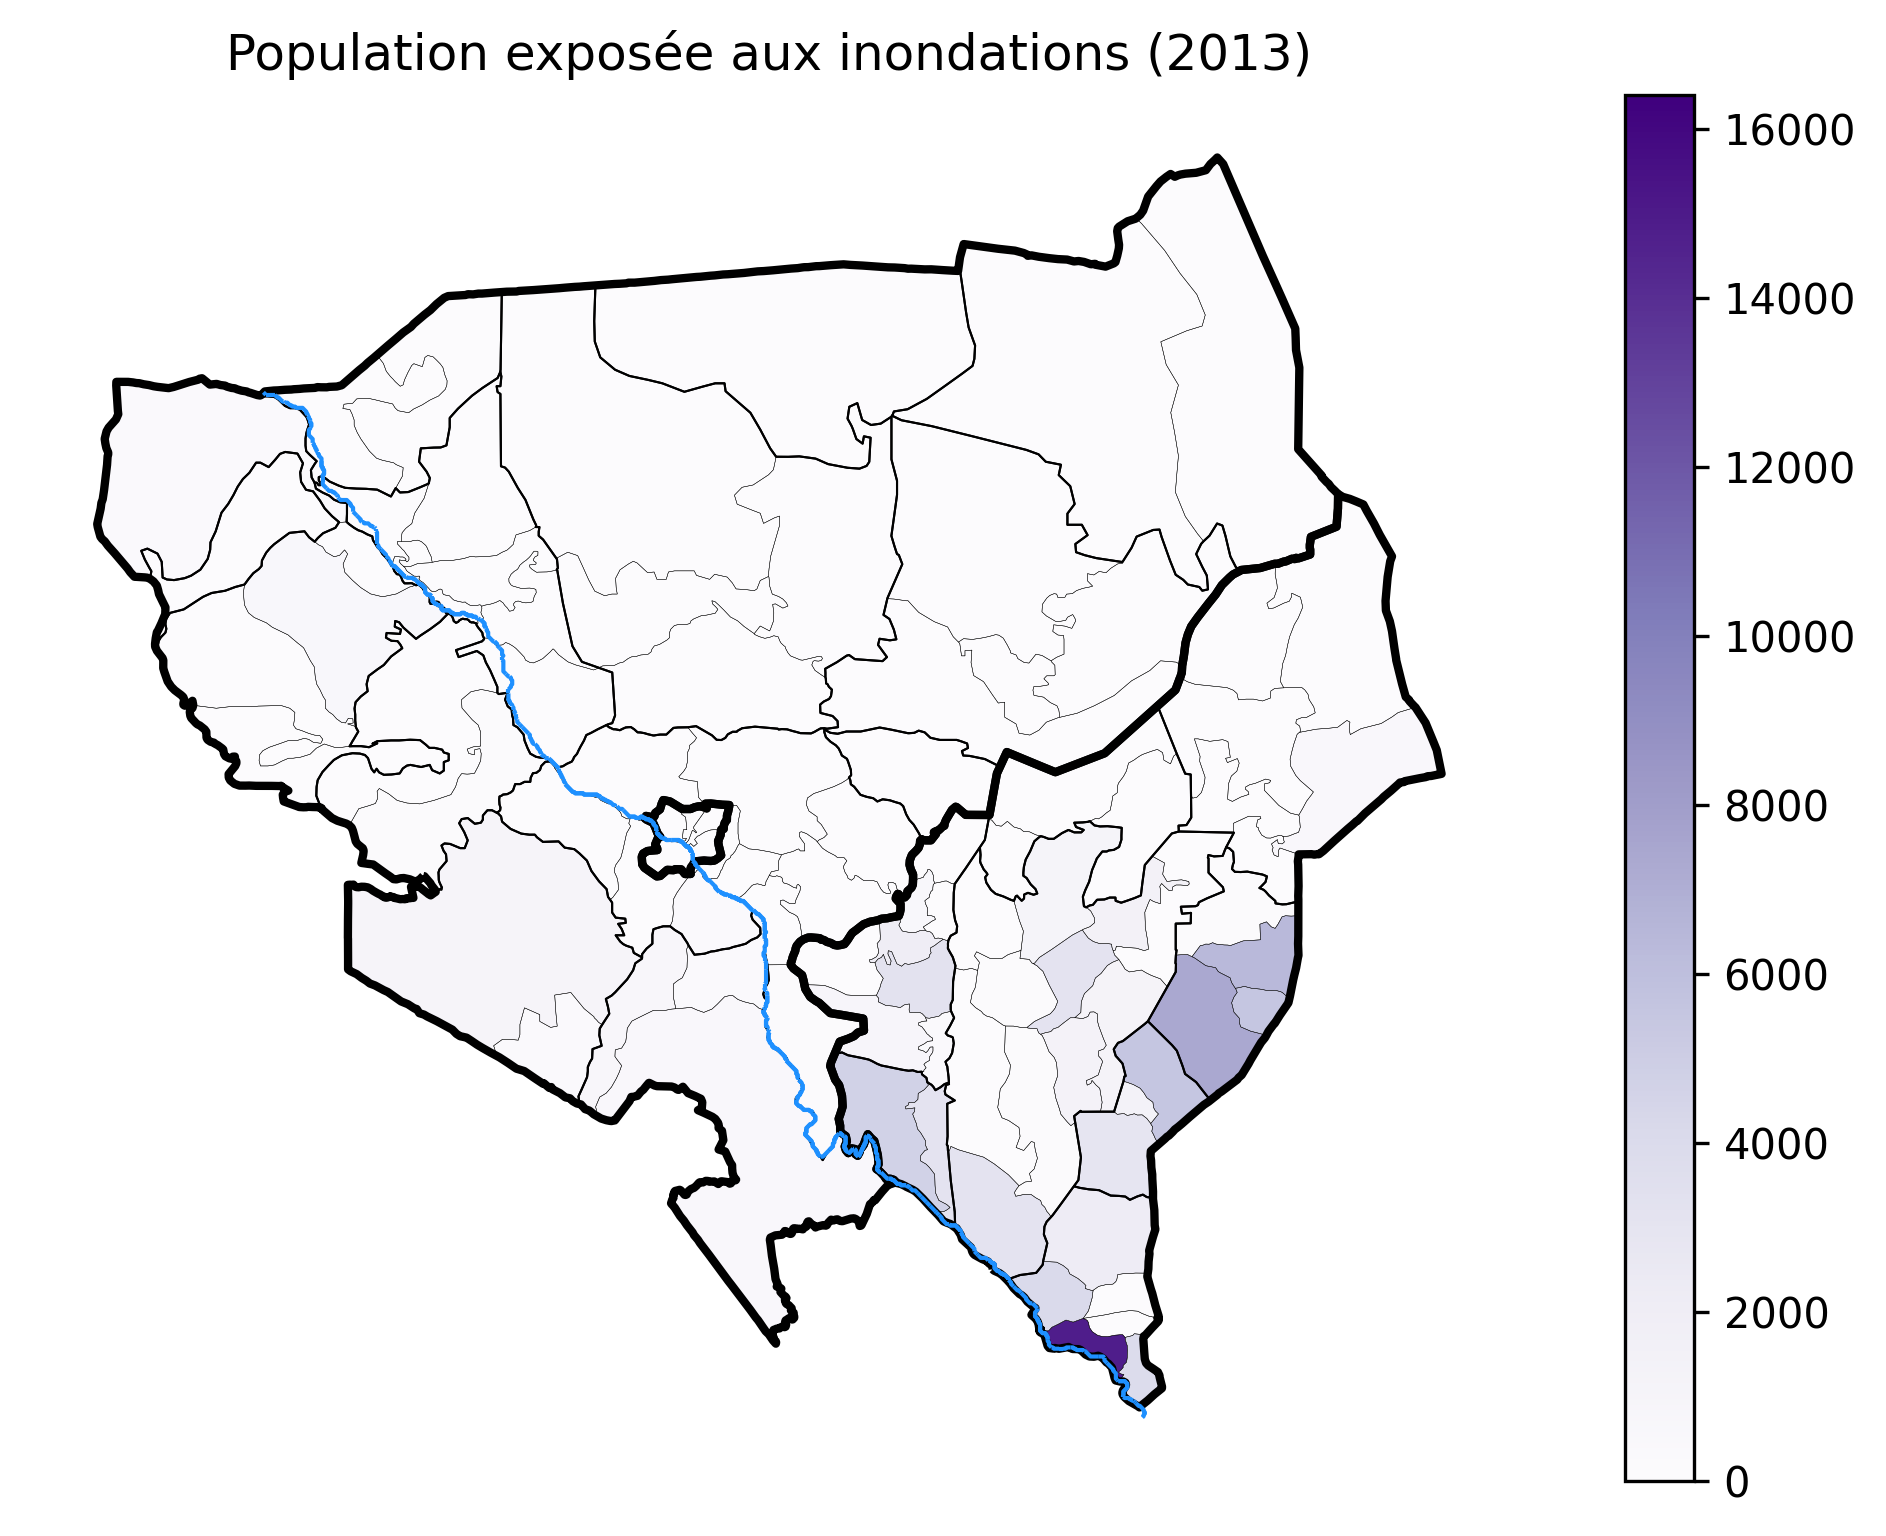

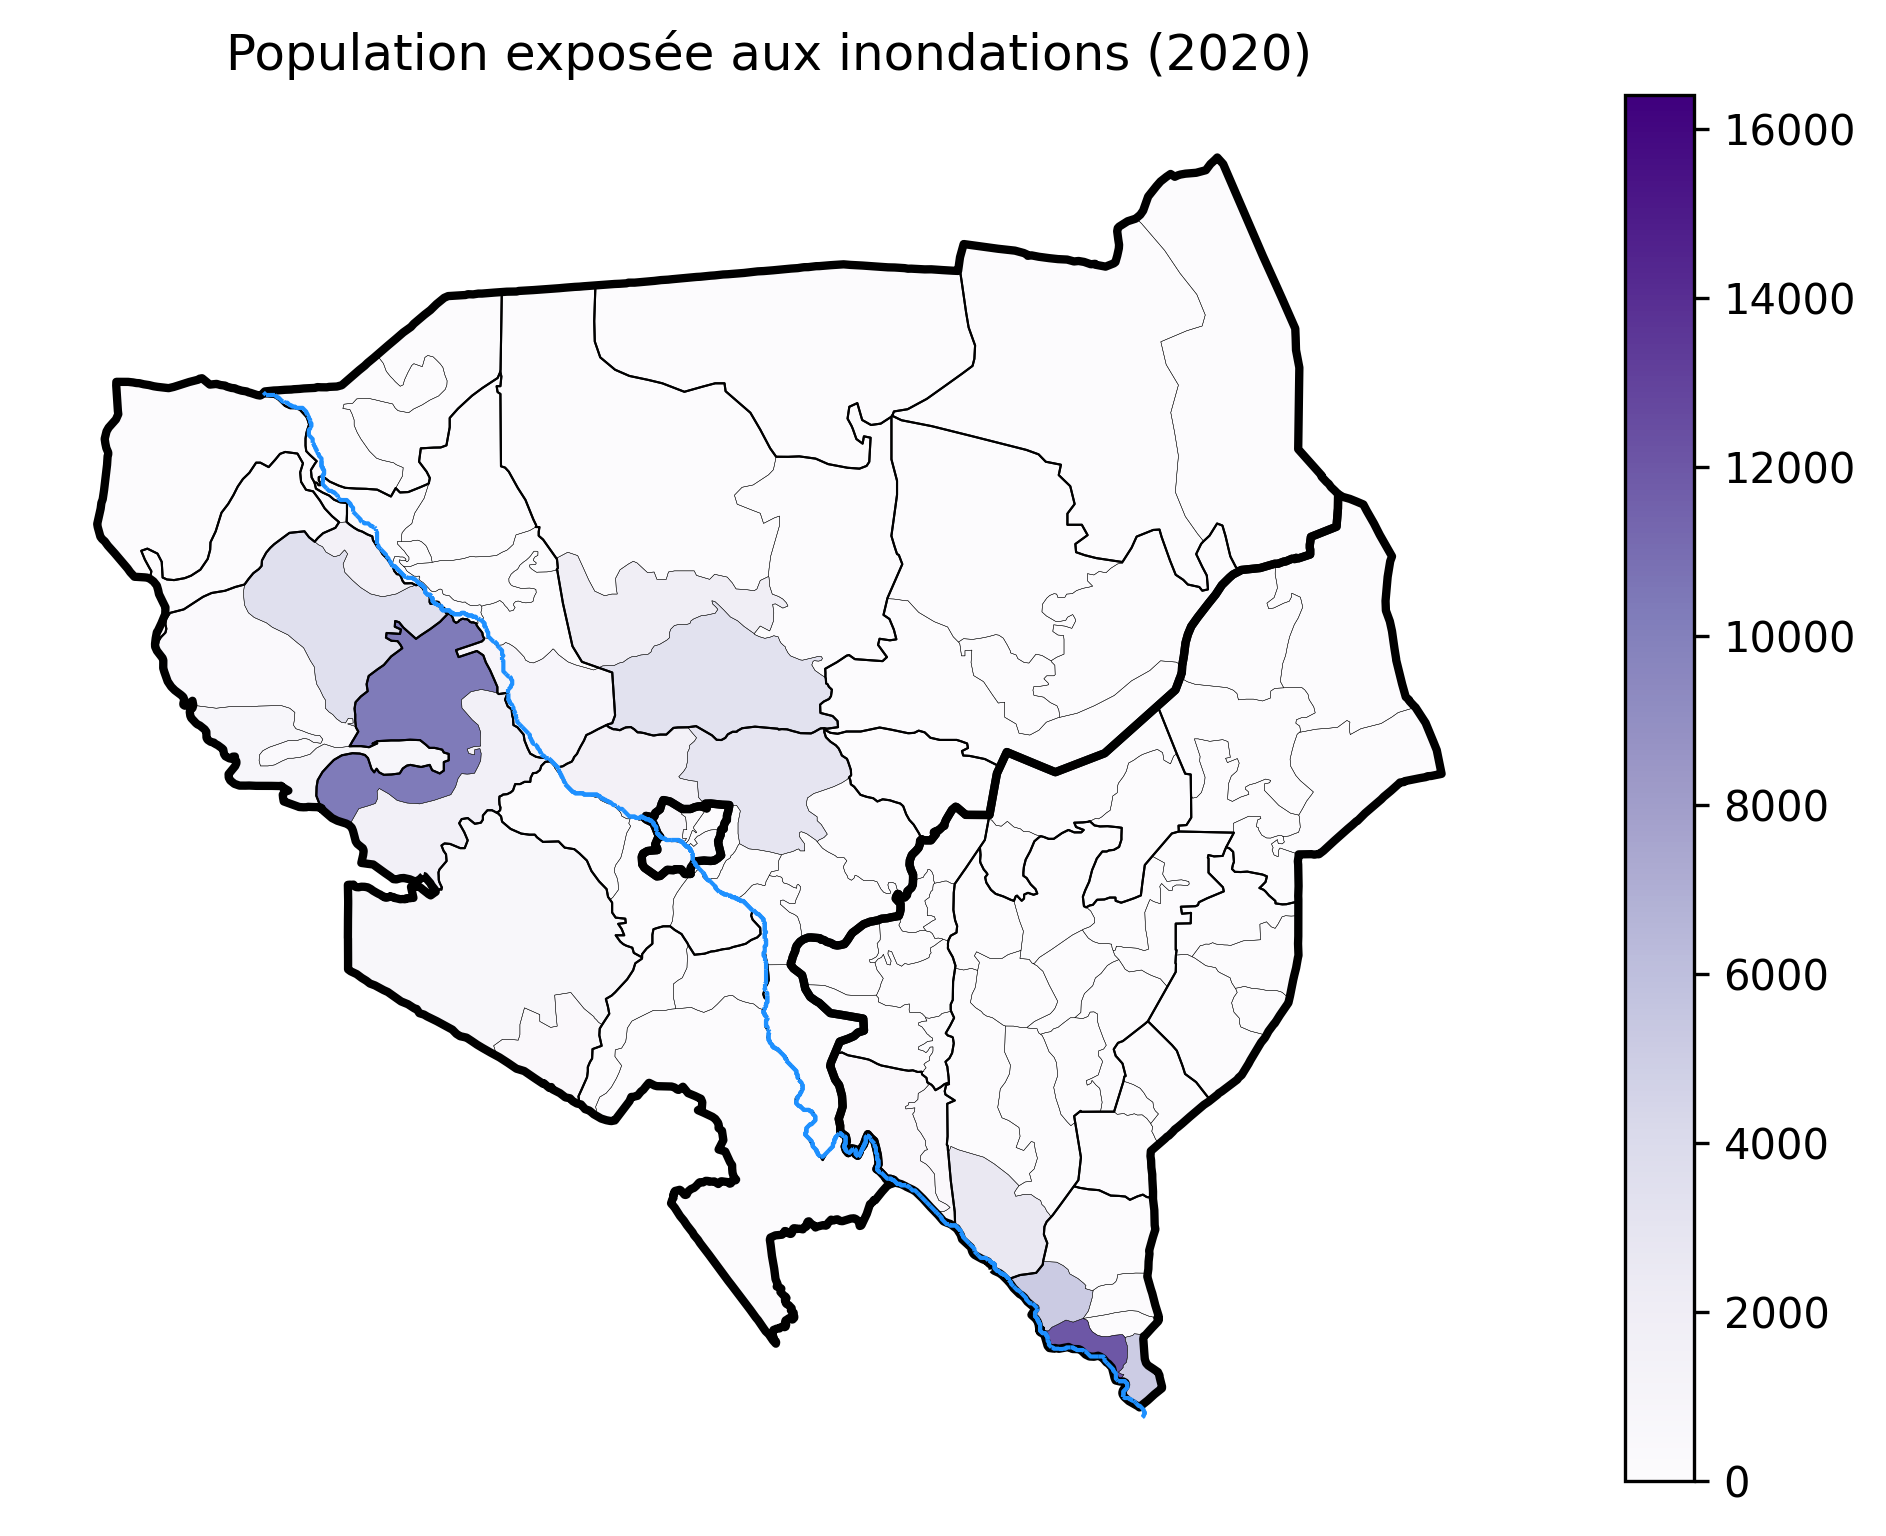

In [287]:
cerf_years = [2009, 2012, 2013, 2020]
vmax = exp_max[exp_max["time"].isin(cerf_years)]["fs_roll3"].max()

for year in cerf_years:
    fig, ax = plt.subplots(figsize=(10, 6), dpi=300)
    ax = adm3.merge(exp_max.set_index("time").loc[year], on="ADM3_PCODE").plot(
        column="fs_roll3", cmap="Purples", ax=ax, legend=True, vmax=vmax
    )
    adm3.boundary.plot(ax=ax, color="k", linewidth=0.1)
    adm2.boundary.plot(ax=ax, color="k", linewidth=0.5)
    adm1.boundary.plot(ax=ax, color="k", linewidth=2)
    river_aoi.plot(ax=ax, color="dodgerblue", linewidth=1)
    ax.axis("off")
    ax.set_title(f"Population exposée aux inondations ({year})")